In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Configuration globale Seaborn — s'applique à TOUS les graphiques
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# Charger le fichier
df = pd.read_csv("C:/Users/HP/Downloads/DANHOMÈ_INTEL_final_clean.csv")

# Ordre correct des mois (pour trier chronologiquement)
MONTH_ORDER = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
MONTH_SHORT  = ["Jan","Fév","Mar","Avr","Mai","Juin",
                "Juil","Aoû","Sep","Oct","Nov","Déc"]

df["month_num"]   = df["month_name"].apply(
    lambda x: MONTH_ORDER.index(x)+1 if x in MONTH_ORDER else 0)
df["month_short"] = df["month_num"].apply(lambda x: MONTH_SHORT[x-1])

print(f"Dataset chargé : {df.shape[0]:,} événements · {df.shape[1]} colonnes")

Dataset chargé : 14,897 événements · 26 colonnes


A

In [3]:
# Vue d'ensemble en une cellule
print("Shape :", df.shape)
print("\nTypes :\n", df.dtypes)
print("\nValeurs nulles :\n", df.isnull().sum())
print("\nAperçu :\n", df.head(3).to_string())

# Valeurs uniques des colonnes catégorielles
for col in ["quad_class","actor1_type","month_name","geo_type"]:
    print(f"\n{col} ({df[col].nunique()} uniques) :")
    print(df[col].value_counts().head(8))

Shape : (14897, 26)

Types :
 date                 object
year                  int64
actor1_name          object
actor1_type          object
actor2_name          object
actor2_type          object
event_code            int64
event_base_code       int64
event_root_code       int64
quad_class            int64
goldstein_scale     float64
num_mentions          int64
num_sources           int64
num_articles          int64
avg_tone            float64
geo_type              int64
geo_full_name        object
geo_country_code     object
geo_adm1_code        object
latitude            float64
longitude           float64
source_url           object
has_actor2            int64
month_name           object
month_num             int64
month_short          object
dtype: object

Valeurs nulles :
 date                0
year                0
actor1_name         0
actor1_type         0
actor2_name         0
actor2_type         0
event_code          0
event_base_code     0
event_root_code     0
quad_class 

B

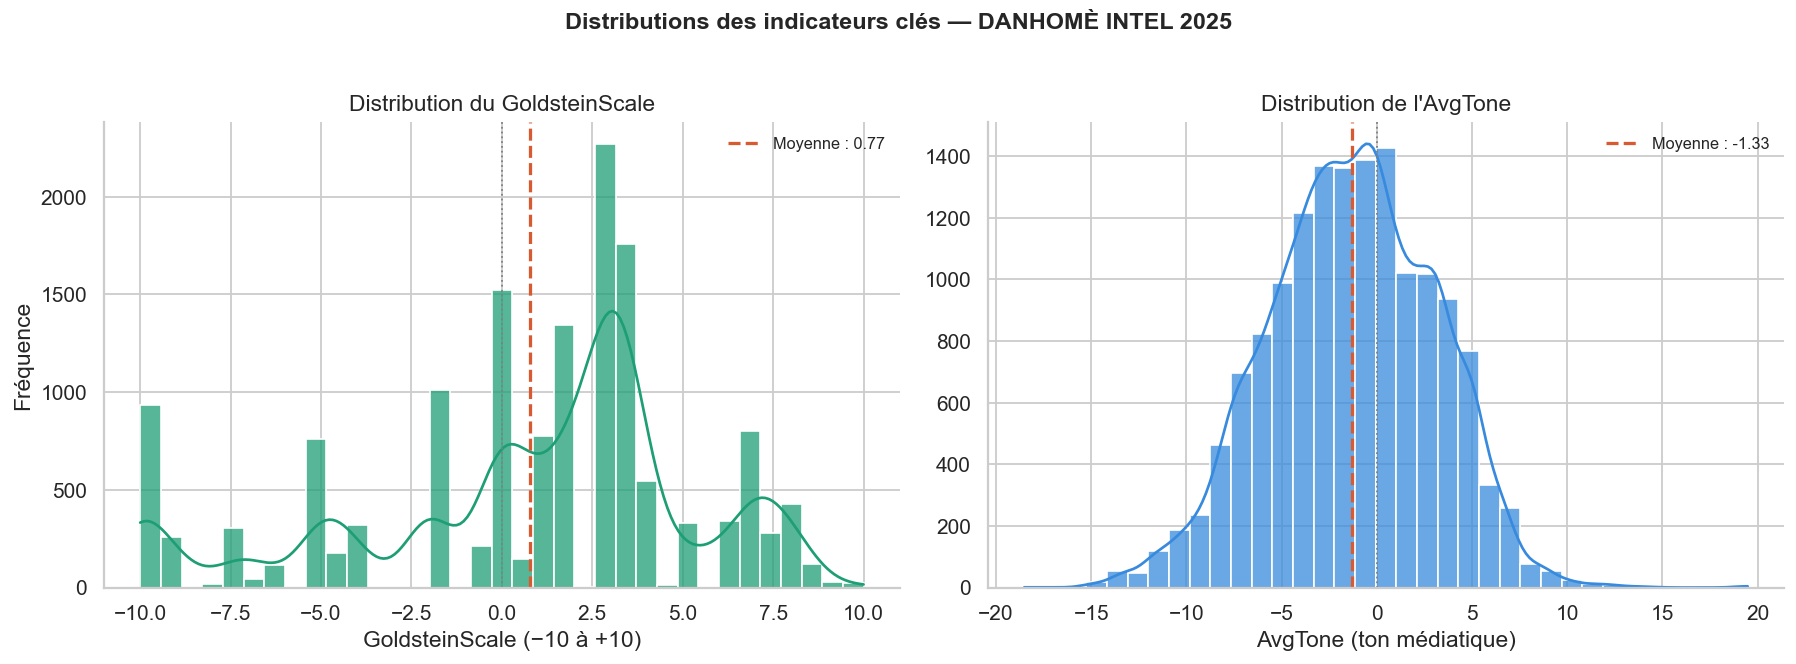

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Goldstein ---
sns.histplot(df["goldstein_scale"], bins=35, kde=True,
             ax=axes[0], color="#1D9E75", alpha=0.75)
axes[0].axvline(df["goldstein_scale"].mean(),
                color="#D85A30", linestyle="--", linewidth=1.8,
                label=f"Moyenne : {df['goldstein_scale'].mean():.2f}")
axes[0].axvline(0, color="gray", linestyle=":", linewidth=1)
axes[0].set_title("Distribution du GoldsteinScale")
axes[0].set_xlabel("GoldsteinScale (−10 à +10)")
axes[0].set_ylabel("Fréquence")
axes[0].legend(fontsize=9, frameon=False)

# --- AvgTone ---
sns.histplot(df["avg_tone"], bins=35, kde=True,
             ax=axes[1], color="#378ADD", alpha=0.75)
axes[1].axvline(df["avg_tone"].mean(),
                color="#D85A30", linestyle="--", linewidth=1.8,
                label=f"Moyenne : {df['avg_tone'].mean():.2f}")
axes[1].axvline(0, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Distribution de l'AvgTone")
axes[1].set_xlabel("AvgTone (ton médiatique)")
axes[1].set_ylabel("")
axes[1].legend(fontsize=9, frameon=False)
plt.suptitle("Distributions des indicateurs clés — DANHOMÈ INTEL 2025",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig1_distributions.png", dpi=130, bbox_inches="tight")
plt.show()

Le GoldsteinScale moyen de +0.77 indique que les événements enregistrés au Bénin en 2025 ont un potentiel théorique légèrement stabilisateur. La distribution montre une majorité d'événements à impact positif, mais révèle aussi environ 1 000 événements au score minimal de −10 — des événements très déstabilisateurs qui méritent une analyse approfondie. La forme multimodale de la distribution reflète la nature catégorielle du système CAMEO, qui attribue des scores fixes selon le type d'événement.
Parallèlement, l'AvgTone moyen de −1.33 indique que les articles couvrant ces événements adoptent un ton globalement négatif. Ce phénomène est structurel dans GDELT : les médias internationaux surreprésentent les crises et les tensions dans leur couverture des pays en développement, ce qui tire mécaniquement le ton vers le bas indépendamment de la réalité terrain.

Evolution temporelle des variables cibles 

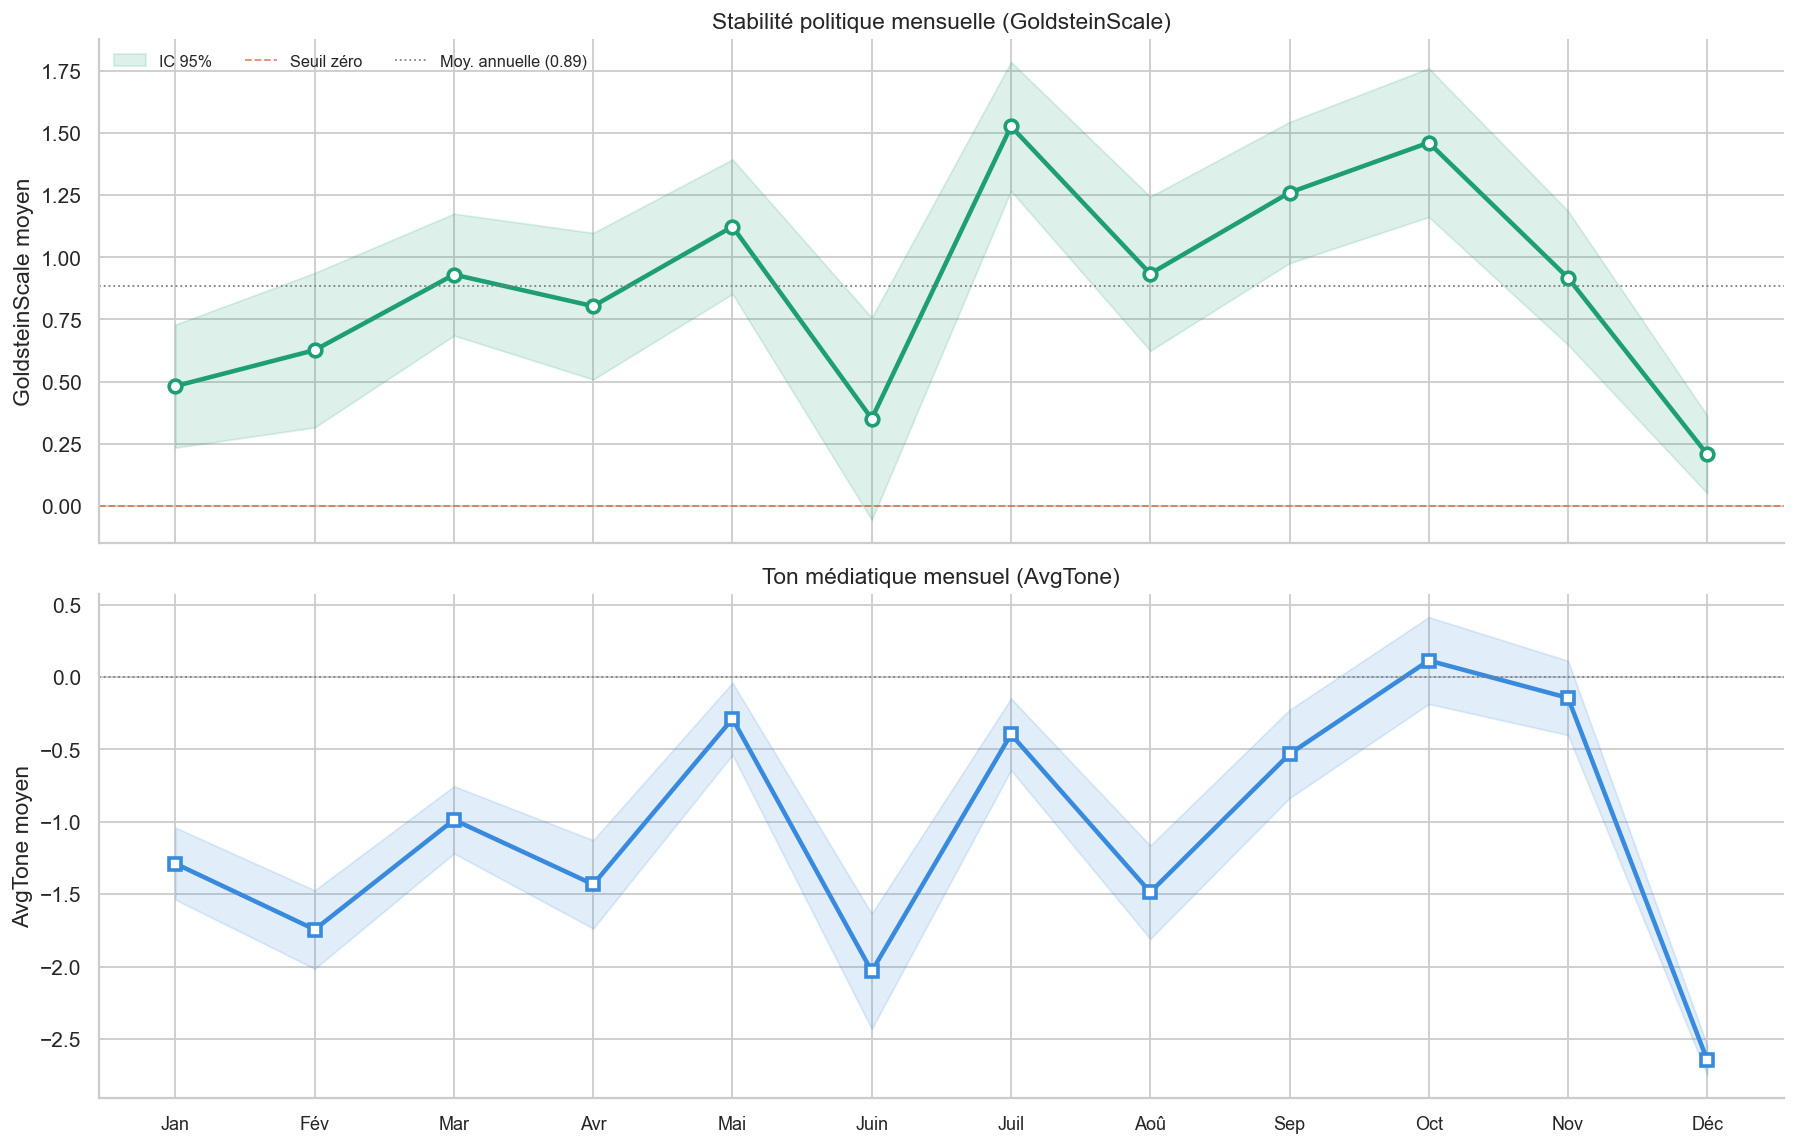

In [5]:
monthly = df.groupby(["month_num","month_short"]).agg(
    avg_goldstein = ("goldstein_scale", "mean"),
    std_goldstein = ("goldstein_scale", "std"),
    avg_tone      = ("avg_tone",        "mean"),
    std_tone      = ("avg_tone",        "std"),
    num_events    = ("event_code",      "count"),
    pct_conflict  = ("quad_class", lambda x: (x==4).mean()*100),
).reset_index().sort_values("month_num")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
xi = np.arange(12)
labels = monthly["month_short"].values

# --- Goldstein avec IC 95% ---
g  = monthly["avg_goldstein"].values
se = monthly["std_goldstein"].values / np.sqrt(monthly["num_events"].values)

axes[0].fill_between(xi, g-1.96*se, g+1.96*se,
                     alpha=0.15, color="#1D9E75", label="IC 95%")
axes[0].plot(xi, g, "o-", color="#1D9E75",
             linewidth=2.5, markersize=7,
             markerfacecolor="white", markeredgewidth=2)
axes[0].axhline(0, color="#D85A30", linestyle="--",
                linewidth=1, alpha=0.7, label="Seuil zéro")
axes[0].axhline(g.mean(), color="gray", linestyle=":",
                linewidth=1, label=f"Moy. annuelle ({g.mean():.2f})")

axes[0].set_ylabel("GoldsteinScale moyen")
axes[0].set_title("Stabilité politique mensuelle (GoldsteinScale)")
axes[0].legend(fontsize=9, frameon=False, ncol=3)

# --- AvgTone ---
t  = monthly["avg_tone"].values
st = monthly["std_tone"].values / np.sqrt(monthly["num_events"].values)

axes[1].fill_between(xi, t-1.96*st, t+1.96*st,
                     alpha=0.15, color="#378ADD")
axes[1].plot(xi, t, "s-", color="#378ADD",
             linewidth=2.5, markersize=7,
             markerfacecolor="white", markeredgewidth=2)
axes[1].axhline(0, color="gray", linestyle=":", linewidth=1)
axes[1].set_ylabel("AvgTone moyen")
axes[1].set_title("Ton médiatique mensuel (AvgTone)")
axes[1].set_xticks(xi)
axes[1].set_xticklabels(labels, fontsize=10)

plt.tight_layout()
plt.savefig("fig2_evolution.png", dpi=130, bbox_inches="tight")
plt.show()

Le GoldsteinScale mensuel reste positif toute l'année, oscillant entre +0.21 et +1.53, ce qui confirme une stabilité théorique globale. Juillet représente le pic de stabilité (+1.53) tandis que juin et décembre constituent les creux les plus marqués. Le creux de juin est à nuancer — le faible volume d'événements ce mois-là élargit l'intervalle de confiance et rend ce résultat moins fiable. En revanche, la chute de décembre (+0.21, IC serré, 3 609 événements) est statistiquement robuste et mérite une investigation approfondie des événements survenus ce mois.
L'AvgTone suit la même dynamique avec une corrélation positive : les mois de forte stabilité correspondent aux mois de couverture médiatique la moins négative. Cependant l'AvgTone ne devient jamais positif, ce qui confirme le biais structurel des médias internationaux vis-à-vis du Bénin indépendamment du contexte.

Matrice des correlations 

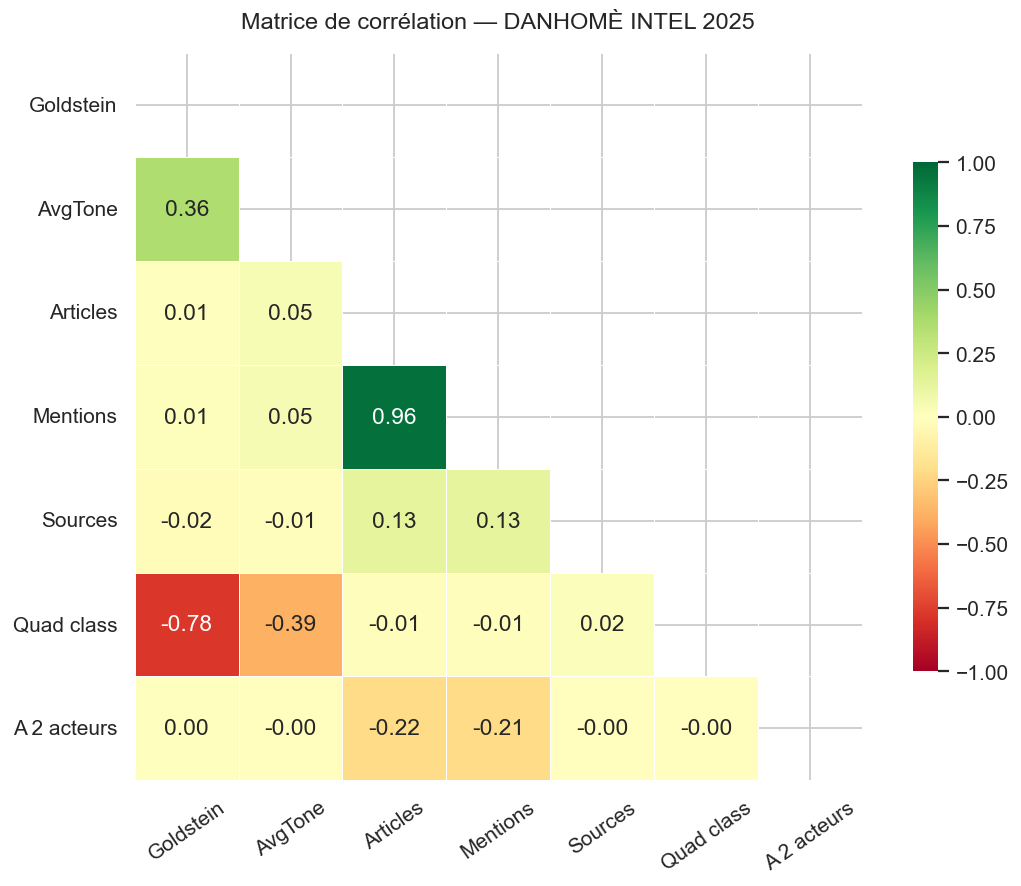

In [6]:
cols = ["goldstein_scale","avg_tone","num_articles",
        "num_mentions","num_sources","quad_class","has_actor2"]
labels_corr = ["Goldstein","AvgTone","Articles",
               "Mentions","Sources","Quad class","A 2 acteurs"]

corr = df[cols].corr()
corr.index   = labels_corr
corr.columns = labels_corr

# Masque triangle supérieur (évite la redondance)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask,
            annot=True, fmt=".2f",
            cmap="RdYlGn", center=0,
            vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.7}, ax=ax)

ax.set_title("Matrice de corrélation — DANHOMÈ INTEL 2025",
             fontsize=13, pad=14)
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("fig3_correlation.png", dpi=130, bbox_inches="tight")
plt.show()

La matrice révèle deux groupes de variables fortement liées entre elles : d'un côté Goldstein et Quad class (r=−0.78) qui mesurent tous les deux la nature de l'événement, de l'autre Articles et Mentions (r=+0.96) qui mesurent tous les deux la visibilité médiatique. Pour le modèle ML, il faudra éviter d'utiliser des variables redondantes de chaque groupe pour ne pas introduire de multicolinéarité.

E

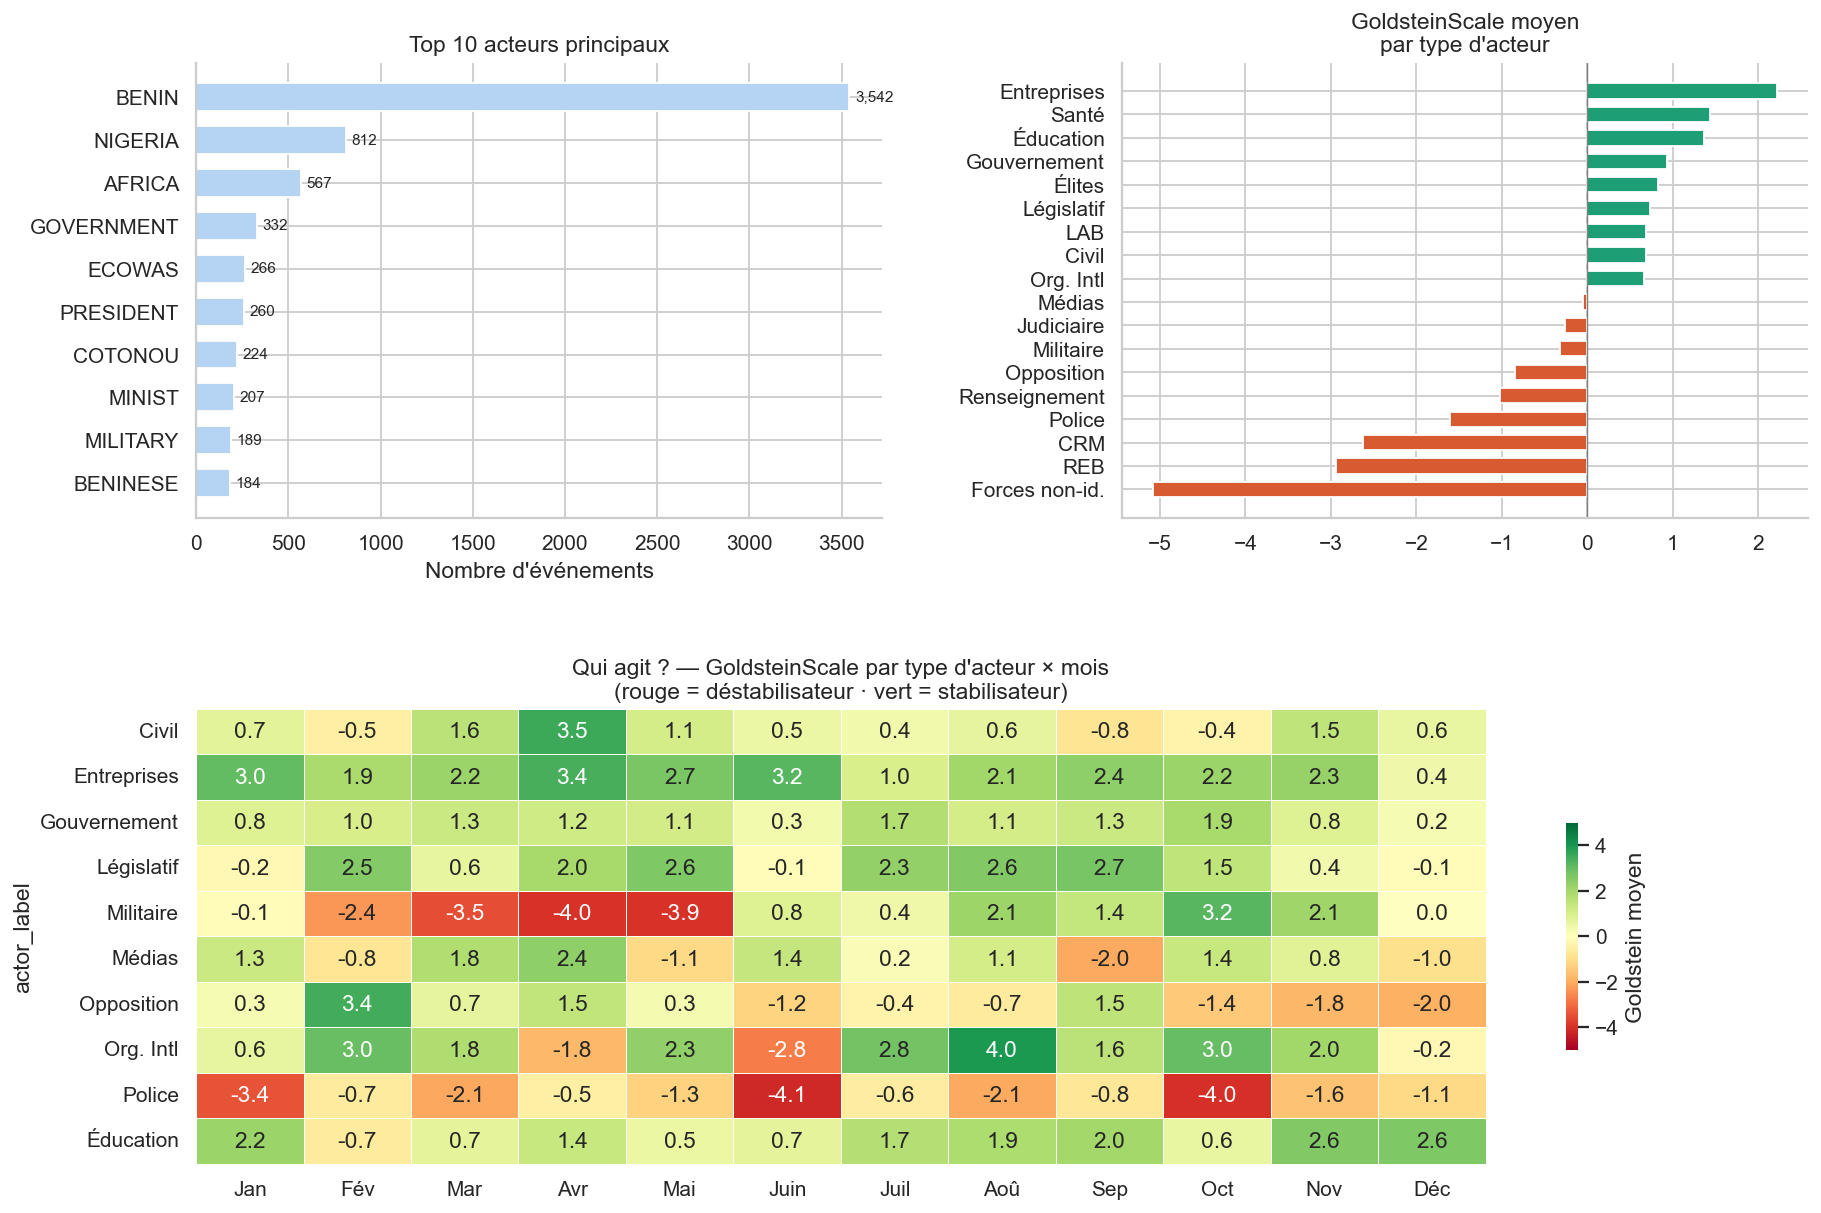

In [7]:
CAMEO = {"GOV":"Gouvernement","COP":"Police","MIL":"Militaire",
         "CVL":"Civil","LEG":"Législatif","EDU":"Éducation",
         "IGO":"Org. Intl","MED":"Médias","BUS":"Entreprises",
         "JUD":"Judiciaire","OPP":"Opposition","UAF":"Forces non-id.",
         "ELI":"Élites","SPY":"Renseignement","HLH":"Santé"}

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.42, wspace=0.35)

# 6a — Top acteurs (barh)
ax1 = fig.add_subplot(gs[0, 0])
top_act = (df[~df["actor1_name"].isin(["Acteur non identifié","Unknown"])]
           ["actor1_name"].value_counts().head(10).reset_index())
top_act.columns = ["actor","count"]
top_act = top_act.sort_values("count")
ax1.barh(top_act["actor"], top_act["count"],
         color="#B5D4F4", edgecolor="white", height=0.65)
for i,(v,c) in enumerate(zip(top_act["actor"],top_act["count"])):
    ax1.text(c+30, i, f"{c:,}", va="center", fontsize=8.5)
ax1.set_title("Top 10 acteurs principaux")
ax1.set_xlabel("Nombre d'événements")

# 6b — Goldstein moyen par type acteur (barh)
ax2 = fig.add_subplot(gs[0, 1])
act_stats = (df[df["actor1_type"] != "UNKNOWN"]
             .groupby("actor1_type")
             .agg(count=("event_code","count"),
                  avg_g=("goldstein_scale","mean"))
             .reset_index()
             .query("count >= 30")
             .sort_values("avg_g"))
act_stats["label"] = (act_stats["actor1_type"]
                      .map(CAMEO)
                      .fillna(act_stats["actor1_type"]))
colors_g = ["#D85A30" if g < 0 else "#1D9E75"
            for g in act_stats["avg_g"]]
ax2.barh(act_stats["label"], act_stats["avg_g"],
         color=colors_g, edgecolor="white", height=0.65)
ax2.axvline(0, color="gray", linewidth=0.8)
ax2.set_title("GoldsteinScale moyen\npar type d'acteur")

# 6c — Heatmap acteur × mois (occupe toute la 2e ligne)
ax3 = fig.add_subplot(gs[1, :])
top_types = ["GOV","MIL","COP","CVL","LEG",
             "EDU","IGO","MED","BUS","OPP"]
df_f = df[df["actor1_type"].isin(top_types)].copy()
df_f["actor_label"] = df_f["actor1_type"].map(CAMEO)

pivot = df_f.pivot_table(
    values="goldstein_scale",
    index="actor_label",
    columns="month_short",
    aggfunc="mean"
)
# Réordonner les mois
col_order = [s for s in MONTH_SHORT if s in pivot.columns]
pivot = pivot.reindex(columns=col_order)

sns.heatmap(pivot, cmap="RdYlGn", center=0,
            vmin=-5, vmax=5,
            annot=True, fmt=".1f",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label":"Goldstein moyen","shrink":0.5},
            ax=ax3)
ax3.set_title("Qui agit ? — GoldsteinScale par type d'acteur × mois\n"
              "(rouge = déstabilisateur · vert = stabilisateur)")
ax3.set_xlabel("")
ax3.tick_params(axis="x", rotation=0)
ax3.tick_params(axis="y", rotation=0)

plt.savefig("fig4_acteurs.png", dpi=130, bbox_inches="tight")
plt.show()

Le Bénin est l'acteur le plus fréquent (3 542 événements), ce qui reflète simplement le fait que GDELT associe le pays à la majorité des événements le concernant. Parmi les types d'acteurs, les Entreprises et l'Éducation sont les plus stabilisateurs (+2 en moyenne), tandis que les Forces non-identifiées (−5) et la Police (négative toute l'année) sont les acteurs les plus déstabilisateurs.
La heatmap confirme le creux de juin observé sur le lineplot : la Police atteint −4.1 et les Organisations Internationales −2.8 ce mois-là, probablement en réaction à une crise sécuritaire. Le Militaire présente un profil bipolaire — très déstabilisateur de février à mai puis stabilisateur de juillet à novembre — ce qui suggère une phase de crise suivie d'opérations de sécurisation. Enfin, la dégradation progressive du score de l'Opposition en fin d'année (−2.0 en décembre) est un signal politique à surveiller.

E

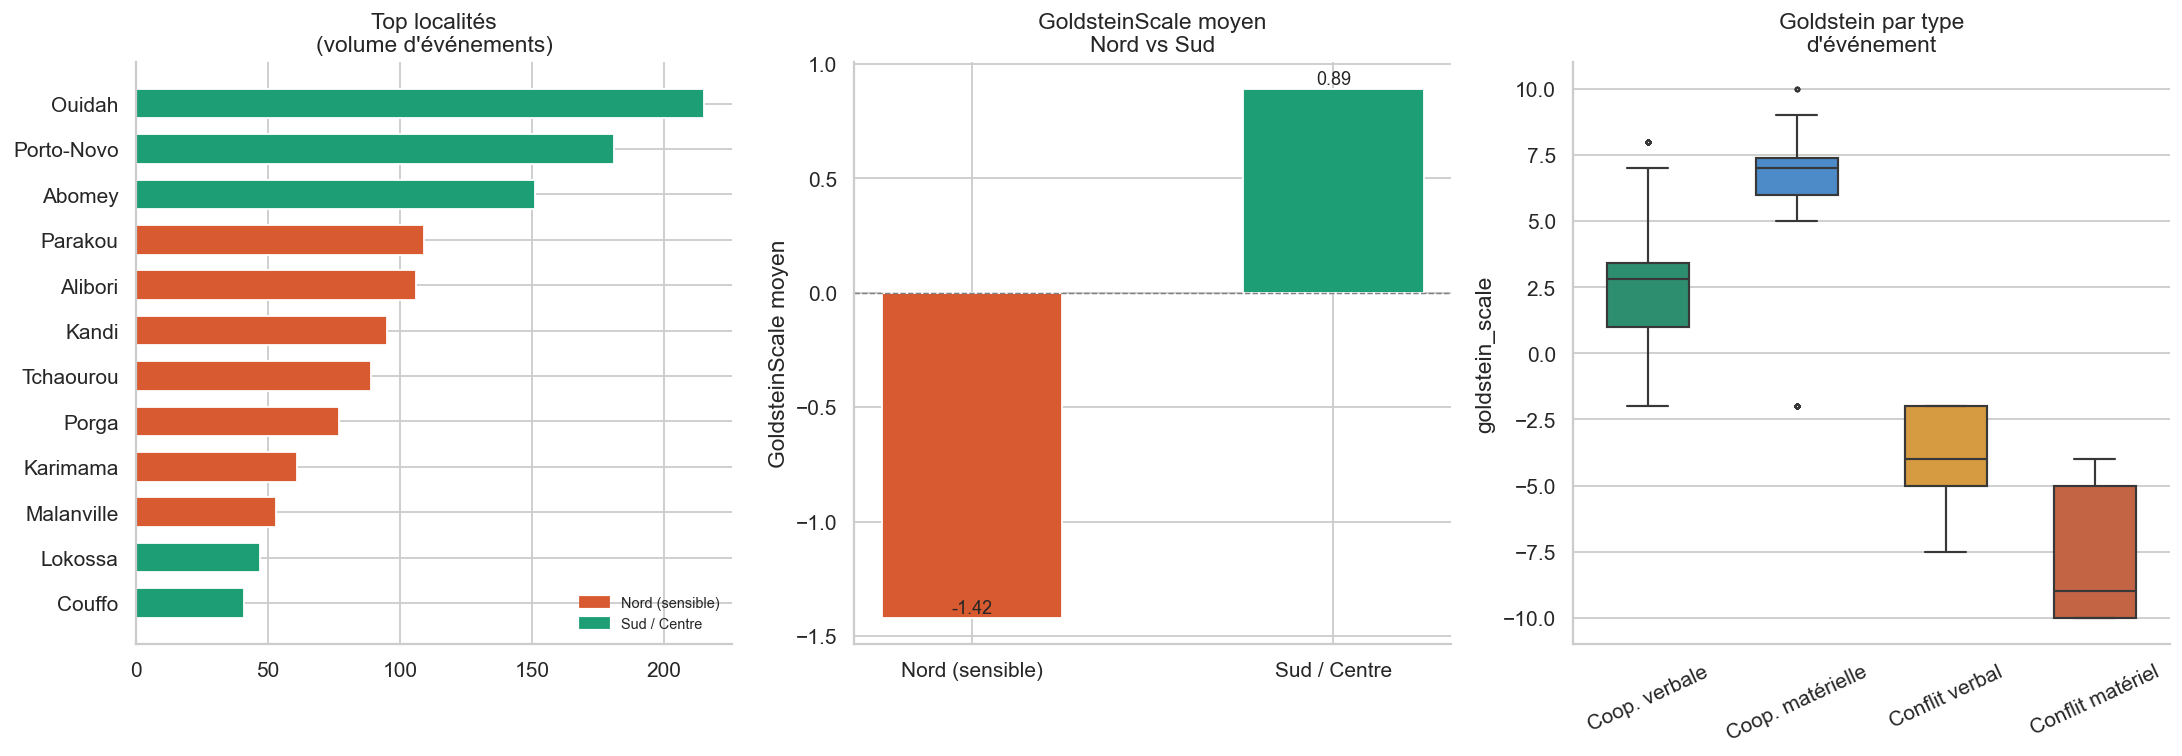

In [8]:
north_kw = ["Alibori","Kandi","Porga","Karimama",
            "Atakora","Djougou","Parakou","Tchaourou",
            "Tanguieta","Malanville"]

df["zone"] = df["geo_full_name"].apply(
    lambda x: "Nord (sensible)"
              if any(k in str(x) for k in north_kw)
              else "Sud / Centre")

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# 7a — Top localités par volume
locs = (df[df["geo_full_name"] != "Benin"]
        ["geo_full_name"].value_counts().head(12)
        .reset_index())
locs.columns = ["loc","count"]
locs["city"] = locs["loc"].apply(lambda x: x.split(",")[0].strip())
locs = locs.sort_values("count")
colors_loc = ["#D85A30" if any(k in l for k in north_kw)
              else "#1D9E75" for l in locs["loc"]]
axes[0].barh(locs["city"], locs["count"],
             color=colors_loc, edgecolor="white", height=0.65)
axes[0].set_title("Top localités\n(volume d'événements)")
legend = [mpatches.Patch(color="#D85A30", label="Nord (sensible)"),
          mpatches.Patch(color="#1D9E75", label="Sud / Centre")]
axes[0].legend(handles=legend, fontsize=8, frameon=False)

# 7b — Goldstein par zone
zone_stats = df.groupby("zone").agg(
    avg_g = ("goldstein_scale","mean"),
    pct_c = ("quad_class", lambda x:(x==4).mean()*100),
    count = ("event_code","count")
).reset_index()
colors_z = ["#D85A30","#1D9E75"]
axes[1].bar(zone_stats["zone"], zone_stats["avg_g"],
            color=colors_z, edgecolor="white", width=0.5)
for i,(v,c) in enumerate(zip(zone_stats["zone"],
                              zone_stats["avg_g"])):
    axes[1].text(i, c+0.02, f"{c:.2f}", ha="center", fontsize=10)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("GoldsteinScale moyen\nNord vs Sud")
axes[1].set_ylabel("GoldsteinScale moyen")

# 7c — Boxplot Goldstein par quad_class
QUAD_L = {1:"Coop. verbale",2:"Coop. matérielle",
          3:"Conflit verbal",4:"Conflit matériel"}
QUAD_C = {1:"#1D9E75",2:"#378ADD",3:"#EF9F27",4:"#D85A30"}
df["quad_label"] = df["quad_class"].map(QUAD_L)
order = [QUAD_L[k] for k in [1,2,3,4]]
palette = {QUAD_L[k]: QUAD_C[k] for k in [1,2,3,4]}
sns.boxplot(data=df, x="quad_label", y="goldstein_scale",
            order=order, palette=palette, ax=axes[2],
            width=0.55, linewidth=1.2,
            flierprops=dict(marker="o",markersize=2,alpha=0.3))
axes[2].set_title("Goldstein par type\nd'événement")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("fig5_geo.png", dpi=130, bbox_inches="tight")
plt.show()

La comparaison géographique révèle un contraste fort : les événements localisés au nord du Bénin ont un GoldsteinScale moyen de −1.42, contre +0.89 pour le sud/centre. Les localités nordiques (Alibori, Kandi, Parakou, Porga, Karimama) concentrent à elles seules plus de 500 événements avec un impact systématiquement négatif — c'est le principal signal géographique d'alerte de cette EDA.
Le boxplot confirme que les conflits matériels sont les événements les plus déstabilisateurs (médiane ≈ −9, moustache à −10) et que ce score n'est pas anecdotique — l'absence d'outliers visibles en bas indique que les valeurs extrêmes sont fréquentes. La coopération matérielle (+7) stabilise significativement mieux que la coopération verbale (+2.5), ce qui suggère que des actions concrètes auraient plus d'impact que des déclarations politiques dans les zones à risque.
Hypothèse à vérifier : le rôle de la Police dans l'instabilité du nord. La heatmap précédente montrait un Goldstein police négatif toute l'année — une analyse géographique croisée permettrait de confirmer si cette présence est concentrée au nord.

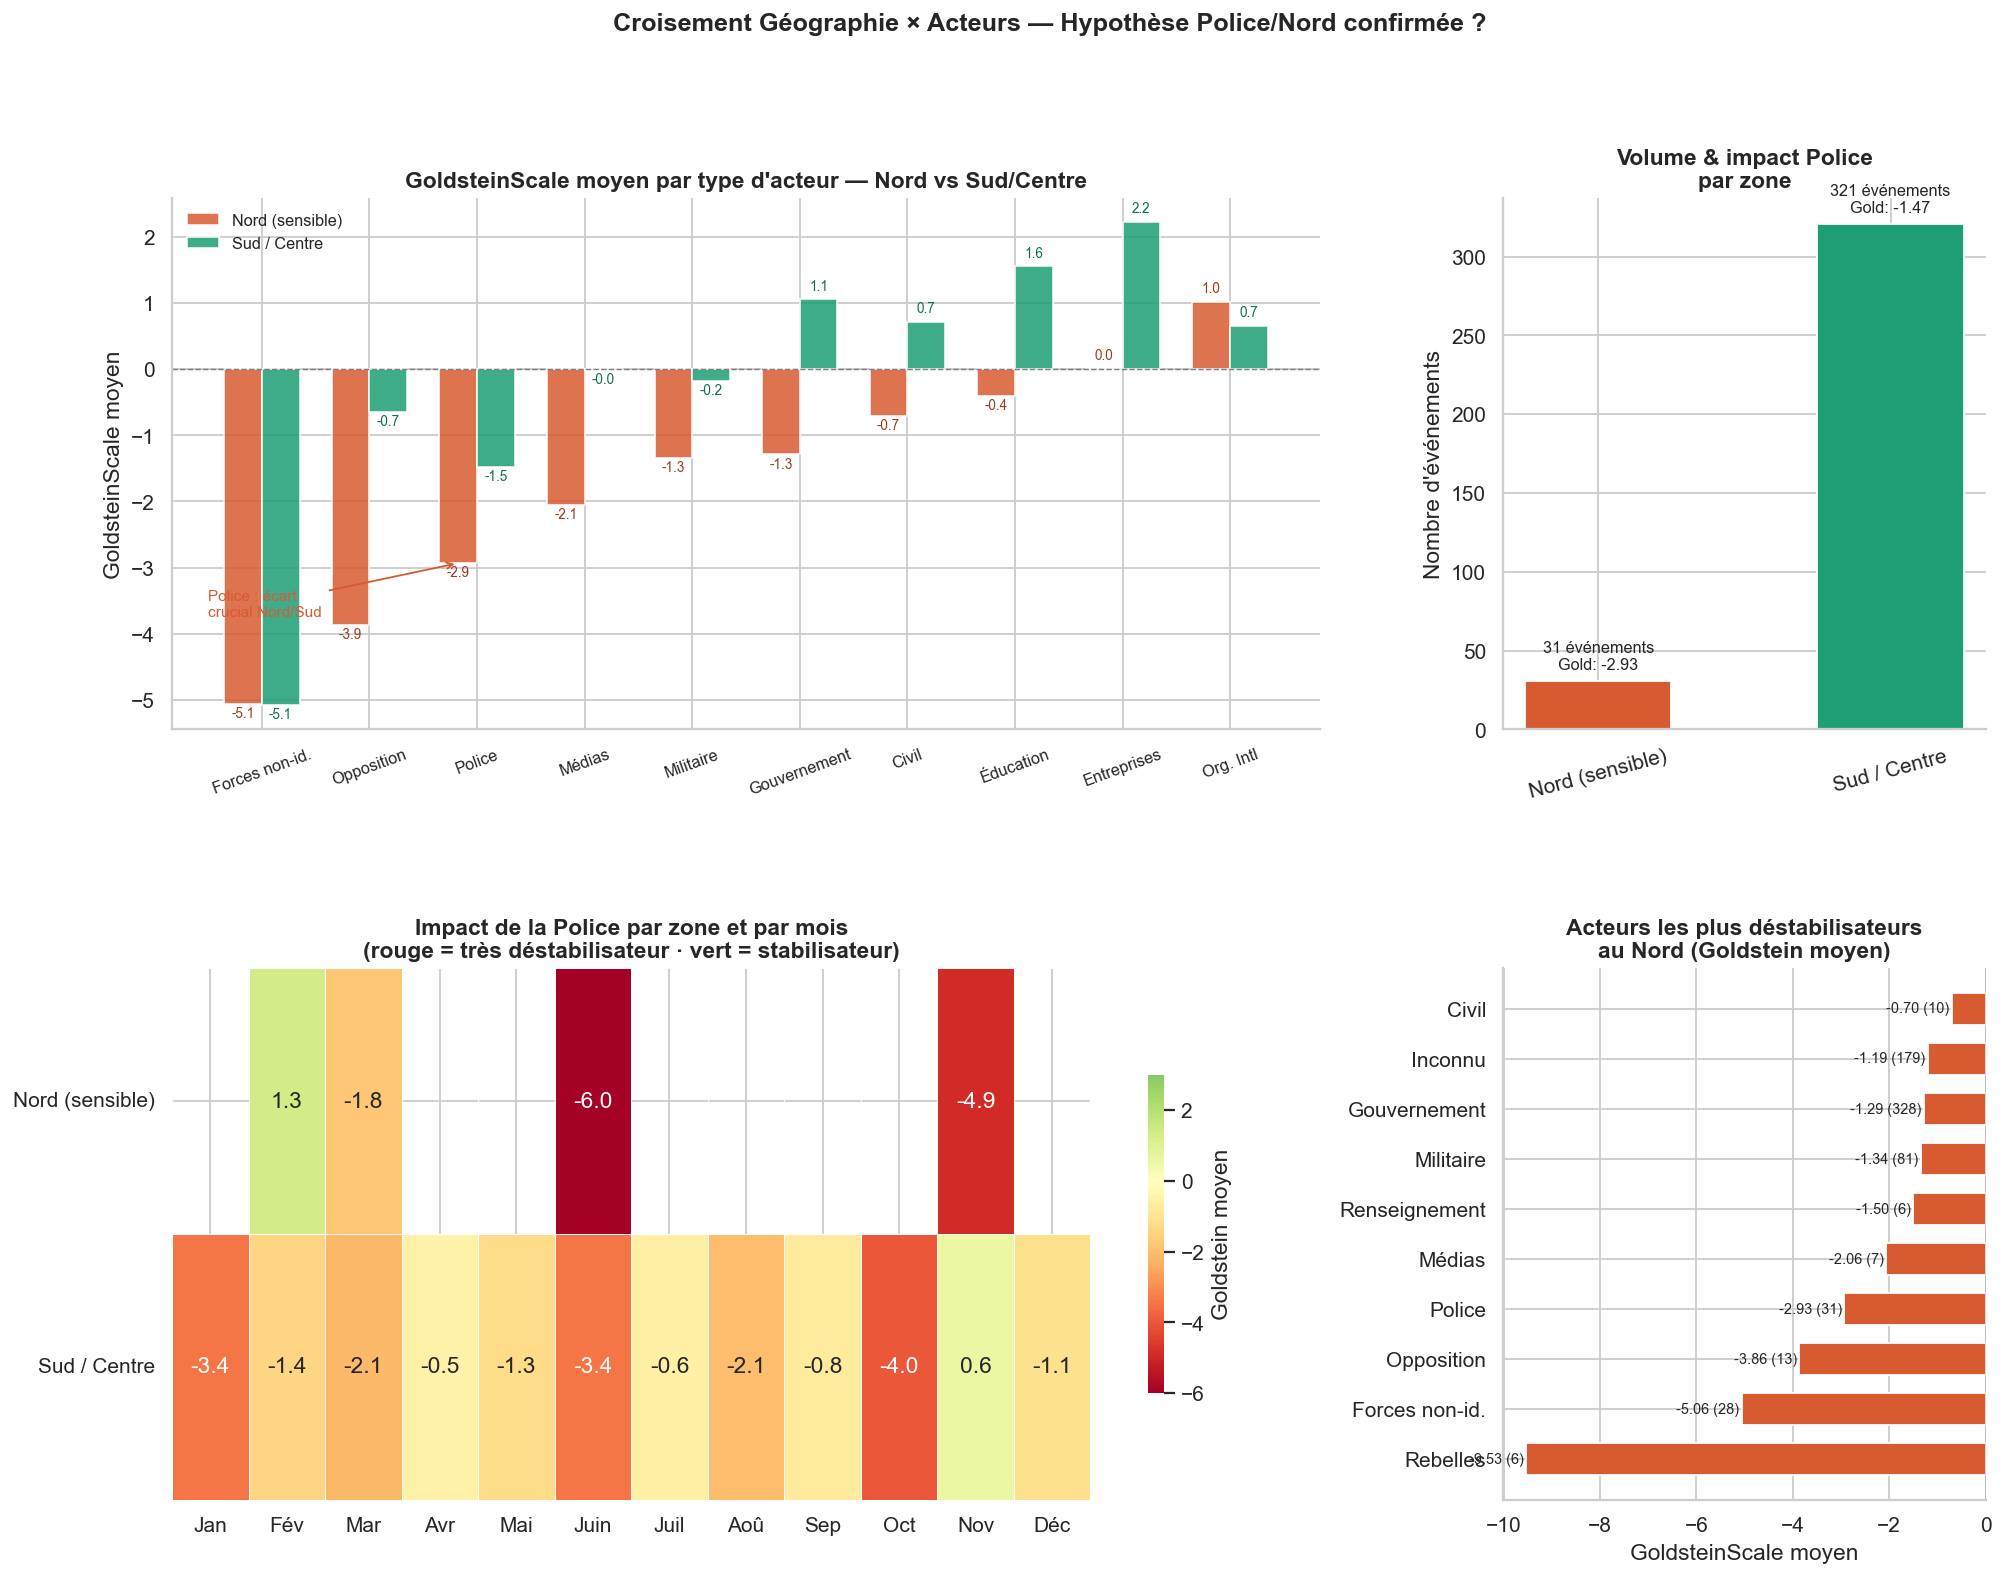

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Préparation ──────────────────────────────────────────────
MONTH_ORDER = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
MONTH_SHORT  = ["Jan","Fév","Mar","Avr","Mai","Juin",
                "Juil","Aoû","Sep","Oct","Nov","Déc"]

df["month_num"]   = df["month_name"].apply(
    lambda x: MONTH_ORDER.index(x)+1 if x in MONTH_ORDER else 0)
df["month_short"] = df["month_num"].apply(lambda x: MONTH_SHORT[x-1])

north_kw = ["Alibori","Kandi","Porga","Karimama","Atakora",
            "Djougou","Parakou","Tchaourou","Tanguieta","Malanville"]

df["zone"] = df["geo_full_name"].apply(
    lambda x: "Nord (sensible)"
              if any(k in str(x) for k in north_kw)
              else "Sud / Centre")

CAMEO = {"GOV":"Gouvernement","COP":"Police","MIL":"Militaire",
         "CVL":"Civil","LEG":"Législatif","EDU":"Éducation",
         "IGO":"Org. Intl","MED":"Médias","BUS":"Entreprises",
         "JUD":"Judiciaire","OPP":"Opposition","UAF":"Forces non-id.",
         "ELI":"Élites","SPY":"Renseignement","REB":"Rebelles",
         "HLH":"Santé","UNKNOWN":"Inconnu"}

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# ── Figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    "Croisement Géographie × Acteurs — Hypothèse Police/Nord confirmée ?",
    fontsize=14, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Graphique 1 — Goldstein moyen par type d'acteur ET par zone ──
ax1 = fig.add_subplot(gs[0, :2])

actor_zone = (
    df[df["actor1_type"].isin(
        ["GOV","COP","MIL","CVL","IGO","OPP","UAF","MED","EDU","BUS"])]
    .groupby(["zone","actor1_type"])
    .agg(avg_gold=("goldstein_scale","mean"),
         count=("event_code","count"))
    .reset_index()
    .query("count >= 5")
)
actor_zone["label"] = actor_zone["actor1_type"].map(CAMEO)

# Pivot pour grouped bar chart
pivot_bar = actor_zone.pivot(
    index="label", columns="zone", values="avg_gold").fillna(0)
pivot_bar = pivot_bar.sort_values("Nord (sensible)")

x     = np.arange(len(pivot_bar))
width = 0.35

bars1 = ax1.bar(x - width/2, pivot_bar["Nord (sensible)"],
                width, color="#D85A30", alpha=0.85,
                label="Nord (sensible)", edgecolor="white")
bars2 = ax1.bar(x + width/2, pivot_bar["Sud / Centre"],
                width, color="#1D9E75", alpha=0.85,
                label="Sud / Centre", edgecolor="white")

# Annoter les valeurs
for bar in bars1:
    v = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2,
             v + (0.1 if v >= 0 else -0.25),
             f"{v:.1f}", ha="center", va="bottom", fontsize=7.5,
             color="#993C1D")
for bar in bars2:
    v = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2,
             v + (0.1 if v >= 0 else -0.25),
             f"{v:.1f}", ha="center", va="bottom", fontsize=7.5,
             color="#0F6E56")

ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(pivot_bar.index, fontsize=9, rotation=20)
ax1.set_ylabel("GoldsteinScale moyen")
ax1.set_title("GoldsteinScale moyen par type d'acteur — Nord vs Sud/Centre",
              fontweight="bold")
ax1.legend(fontsize=9, frameon=False)

# Annotation Police
police_idx = list(pivot_bar.index).index("Police")
ax1.annotate("Police : écart\ncrucial Nord/Sud",
             xy=(police_idx - width/2,
                 pivot_bar.loc["Police","Nord (sensible)"]),
             xytext=(police_idx - 2.5,
                     pivot_bar.loc["Police","Nord (sensible)"] - 0.8),
             arrowprops=dict(arrowstyle="->", color="#D85A30"),
             fontsize=8.5, color="#D85A30")

# ── Graphique 2 — Volume d'événements Police par zone ──────────
ax2 = fig.add_subplot(gs[0, 2])

police_zone = (df[df["actor1_type"] == "COP"]
               .groupby("zone")
               .agg(count=("event_code","count"),
                    avg_gold=("goldstein_scale","mean"))
               .reset_index())

colors_pz = ["#D85A30","#1D9E75"]
bars = ax2.bar(police_zone["zone"], police_zone["count"],
               color=colors_pz, edgecolor="white", width=0.5)

for bar, (_, row) in zip(bars, police_zone.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f"{int(row['count'])} événements\nGold: {row['avg_gold']:.2f}",
             ha="center", va="bottom", fontsize=9)

ax2.set_title("Volume & impact Police\npar zone", fontweight="bold")
ax2.set_ylabel("Nombre d'événements")
ax2.tick_params(axis="x", rotation=15)

# ── Graphique 3 — Heatmap Police × Mois × Zone ─────────────────
ax3 = fig.add_subplot(gs[1, :2])

police_pivot = (
    df[df["actor1_type"] == "COP"]
    .groupby(["zone","month_short"])["goldstein_scale"]
    .mean()
    .unstack()
)
col_order = [s for s in MONTH_SHORT if s in police_pivot.columns]
police_pivot = police_pivot.reindex(columns=col_order)

sns.heatmap(police_pivot, cmap="RdYlGn", center=0,
            vmin=-6, vmax=3,
            annot=True, fmt=".1f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Goldstein moyen","shrink":0.6},
            ax=ax3)
ax3.set_title("Impact de la Police par zone et par mois\n"
              "(rouge = très déstabilisateur · vert = stabilisateur)",
              fontweight="bold")
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.tick_params(axis="x", rotation=0)
ax3.tick_params(axis="y", rotation=0)

# ── Graphique 4 — Top acteurs déstabilisateurs au Nord ─────────
ax4 = fig.add_subplot(gs[1, 2])

north_actors = (
    df[df["zone"] == "Nord (sensible)"]
    .groupby("actor1_type")
    .agg(avg_gold=("goldstein_scale","mean"),
         count=("event_code","count"))
    .reset_index()
    .query("count >= 5")
    .sort_values("avg_gold")
    .head(10)
)
north_actors["label"] = (north_actors["actor1_type"]
                         .map(CAMEO)
                         .fillna(north_actors["actor1_type"]))

colors_na = ["#D85A30" if g < 0 else "#1D9E75"
             for g in north_actors["avg_gold"]]
bars4 = ax4.barh(north_actors["label"], north_actors["avg_gold"],
                 color=colors_na, edgecolor="white", height=0.65)

ax4.axvline(0, color="gray", linewidth=0.8)
for bar, (_, row) in zip(bars4, north_actors.iterrows()):
    v = row["avg_gold"]
    ax4.text(v + (0.05 if v >= 0 else -0.05),
             bar.get_y() + bar.get_height()/2,
             f"{v:.2f} ({int(row['count'])})",
             va="center",
             ha="left" if v >= 0 else "right",
             fontsize=8)

ax4.set_title("Acteurs les plus déstabilisateurs\nau Nord (Goldstein moyen)",
              fontweight="bold")
ax4.set_xlabel("GoldsteinScale moyen")

plt.savefig("fig_police_nord.png", dpi=130, bbox_inches="tight")
plt.show()

L'analyse croisée géographie × acteurs révèle un tableau clair :

1. Le Nord est structurellement instable (Goldstein = −1.42)
   principalement à cause de trois acteurs :
   - Rebelles (−9.53, 6 événements) : rare mais extrême
   - Forces non-identifiées (−5.06, 28 événements) : probablement
     groupes armés non étatiques liés à la menace sahélienne
   - Opposition (−3.86, 13 événements) : tensions politiques locales

2. La Police intervient au Nord dans des contextes de crise
   (−2.93 en moyenne, −6.0 en juin, −4.9 en novembre).
   Son impact négatif reflète probablement la nature des situations
   auxquelles elle répond plutôt qu'une défaillance propre.

3. Juin et Novembre sont les deux mois critiques au Nord —
   les deux seuls moments où la Police y est active avec
   des scores catastrophiques.